## Assignment 3: $k$ Nearest Neighbor


**Q1.**
1. What is the difference between regression and classification?
2. What is a confusion table? What does it help us understand about a model's performance?
3. What does the SSE quantify about a particular model?
4. What are overfitting and underfitting? 
5. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance?
6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the features.
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for the optimal model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Geethan Sundaram

**Date:** 9/30/2026

In [20]:
import textwrap

# Your Phase 1 solution to the problem goes here.
print("-- Question 1.1 --")
question_1_1 = "The difference between regression and classification is that regression predicts numerical values with continuous ranges, while classification predicts discrete labels or categories. An example of a regression problem is predicting the price of a house based on its features, while an example of a classification problem is predicting whether an email is spam or not."
print(textwrap.fill(question_1_1, width=80))
print("\n")
print("-- Question 1.2 --")
question_1_2 = "A confusion table compares a model's predicted labels against the actual labels, which helps evaluate the model's performance by showing us true positives (TP), true negatives (TN), false positives (FP), and false negatives (FN)."
print(textwrap.fill(question_1_2, width=80))
print("\n")
print("-- Question 1.3 --")
question_1_3 = "The SSE or Sum of Squared Errors measures the total deviation of the predicted values from the actual values in a regression model. It is calculated as the sum of the squares of the differences between the predicted and actual values, or SSE = Sigma(y_i - y_hat_i)^2."
print(textwrap.fill(question_1_3, width=80))
print("\n")
print("-- Question 1.4 --")
question_1_4 = "Overfitting happens when a model learns the training data too well, including noise and outliers, which makes it perform poorly on unseen data. Underfitting occurs when a model is trained too simply and doesn't capture the underlying patterns in the data, which leads to it performing poorly on both training and unseen data."
print(textwrap.fill(question_1_4, width=80))
print("\n")
print("-- Question 1.5 --")
question_1_5 = "If we used data solely for training, then we won't have a good idea of how the model works with new data. For example, you cannot detect overfitting or underfitting properly without a separate validation or test set. This is why we split our data into training and testing sets. We use just the training data to train the model then we have testing data to see if the model performs well on unseen data. This helps us avoid overfitting and underfitting. Choosing k for kNN by evaluating the accuracy or SSE on the test set helps us find the optimal value of k that minimizes the error and provides the best performance. Different values of k can lead to different results, so it's important to choose the right one by testing different values and selecting the one that performs best on the test set."
print(textwrap.fill(question_1_5, width=80))
print("\n")
print("-- Question 1.6 --")
question_1_6 = "A classification model can report a class label as a prediction or a probability distribution over all possible classes. A single class label prediction is very simple to interpret and very useful when a single decision must be made, but it tells us nothing about the model's confidence in that prediction. A probability distribution gives us more information about the model's confidence in each class label, which is very useful for decision-making and understanding the model's behavior. But it can be more complex to interpret, especially when there are many classes."
print(textwrap.fill(question_1_6, width=80))

-- Question 1.1 --
The difference between regression and classification is that regression predicts
numerical values with continuous ranges, while classification predicts discrete
labels or categories. An example of a regression problem is predicting the price
of a house based on its features, while an example of a classification problem
is predicting whether an email is spam or not.


-- Question 1.2 --
A confusion table compares a model's predicted labels against the actual labels,
which helps evaluate the model's performance by showing us true positives (TP),
true negatives (TN), false positives (FP), and false negatives (FN).


-- Question 1.3 --
The SSE or Sum of Squared Errors measures the total deviation of the predicted
values from the actual values in a regression model. It is calculated as the sum
of the squares of the differences between the predicted and actual values, or
SSE = Sigma(y_i - y_hat_i)^2.


-- Question 1.4 --
Overfitting happens when a model learns the training

-- Question 2.1 --


,voltage,height,soil,mine_type
0,0.338157,0.000000,0.0,1
1,0.320241,0.181818,0.0,1
2,0.287009,0.272727,0.0,1
3,0.256284,0.454545,0.0,1
4,0.262840,0.545455,0.0,1


Shape: (338, 4)

Data types:
voltage      float64
height       float64
soil         float64
mine_type      int64
dtype: object

Missing values:
voltage      0
height       0
soil         0
mine_type    0
dtype: int64

Mine type counts:
mine_type
1    71
2    70
3    66
4    66
5    65
Name: count, dtype: int64

Mine type proportions:
mine_type
1    0.210059
2    0.207101
3    0.195266
4    0.195266
5    0.192308
Name: proportion, dtype: float64

Feature summary:


,voltage,height,soil
count,338.000000,338.000000,338.000000
mean,0.430634,0.508876,0.503550
std,0.195819,0.306043,0.344244
min,0.197734,0.000000,0.000000
25%,0.309737,0.272727,0.200000
50%,0.359516,0.545455,0.600000
75%,0.482628,0.727273,0.800000
max,0.999999,1.000000,1.000000



Average feature values by mine type:


,voltage,height,soil
mine_type,,,
1,0.296463,0.495519,0.492958
2,0.721123,0.487013,0.508571
3,0.402408,0.527548,0.496970
4,0.345365,0.506887,0.503030
5,0.379598,0.530070,0.516923


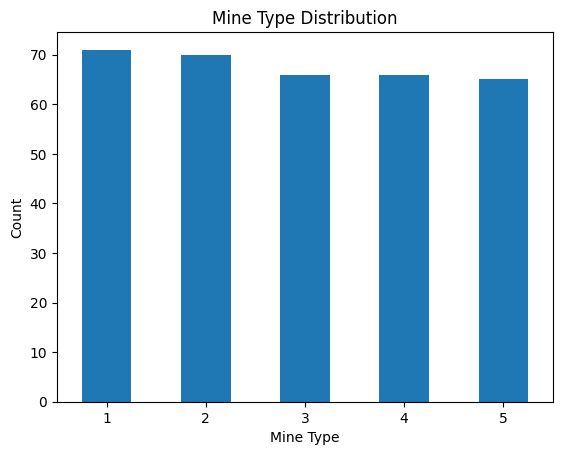

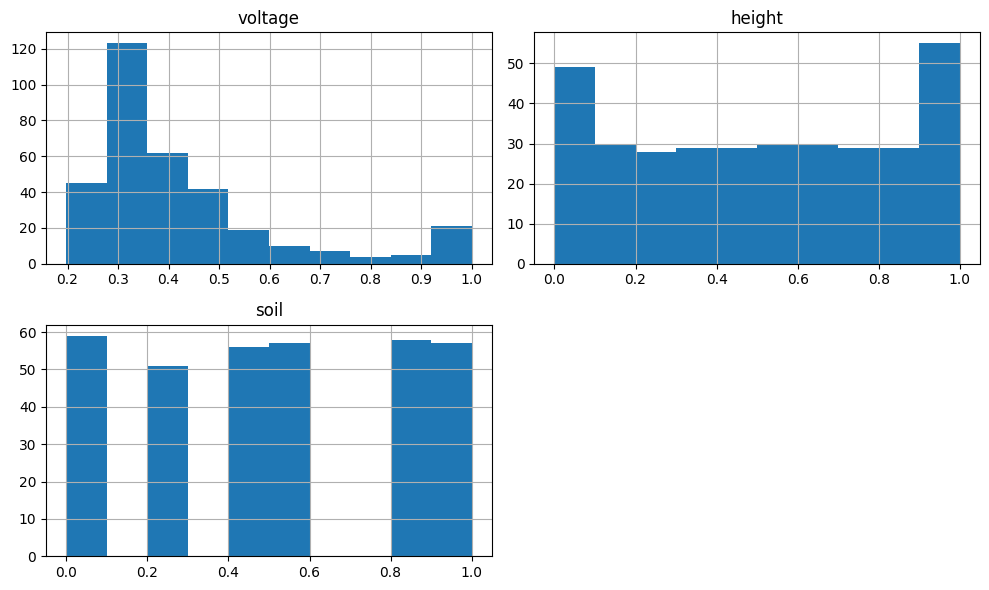

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("-- Question 2.1 --")

import pandas as pd
import matplotlib.pyplot as plt

# Load the data
df = pd.read_csv("data/land_mines.csv")

# Look at the first few rows
display(df.head())

# Basic information
print("Shape:", df.shape)

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isna().sum())

# Target variable counts
print("\nMine type counts:")
print(df["mine_type"].value_counts().sort_index())

print("\nMine type proportions:")
print(df["mine_type"].value_counts(normalize=True).sort_index())

# Summary stats for the features
print("\nFeature summary:")
display(df[["voltage", "height", "soil"]].describe())

# Average feature values by mine type
print("\nAverage feature values by mine type:")
display(
    df.groupby("mine_type")[["voltage", "height", "soil"]].mean()
)

# Plot mine type counts
df["mine_type"].value_counts().sort_index().plot(kind="bar")

plt.xlabel("Mine Type")
plt.ylabel("Count")
plt.title("Mine Type Distribution")
plt.xticks(rotation=0)
plt.show()

# Histograms for the features
df[["voltage", "height", "soil"]].hist(figsize=(10, 6))

plt.tight_layout()
plt.show()

In [22]:
from sklearn.model_selection import train_test_split

print("-- Question 2.2 --")

from sklearn.model_selection import train_test_split

# Predictor variables
X = df[["voltage", "height", "soil"]]

# Target variable
y = df["mine_type"]

# Split 50/50
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.5,
    random_state=42,
    stratify=y
)

print("Training set size:", len(X_train))
print("Test set size:", len(X_test))

print("\nTraining set class counts:")
print(y_train.value_counts().sort_index())

print("\nTest set class counts:")
print(y_test.value_counts().sort_index())

-- Question 2.2 --
Training set size: 169
Test set size: 169

Training set class counts:
mine_type
1    35
2    35
3    33
4    33
5    33
Name: count, dtype: int64

Test set class counts:
mine_type
1    36
2    35
3    33
4    33
5    32
Name: count, dtype: int64


-- Question 2.3 --
Best k: 1
Best accuracy: 0.5088757396449705


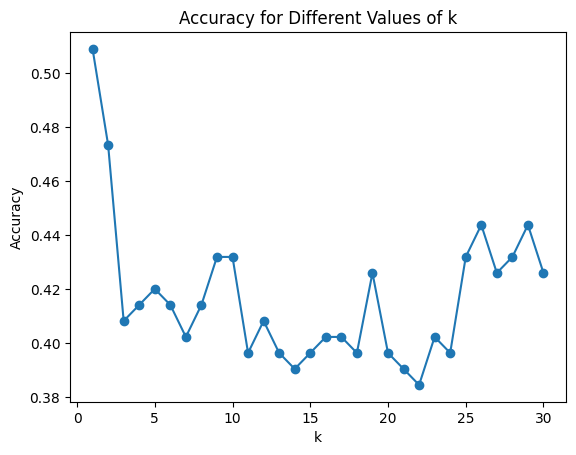

I selected k by evaluating the accuracy of the kNN classifier on the test set
for different values of k (from 1 to 30). I calculated the accuracy for each k
and then identified the value of k with the highest accuracy. With this process,
I ensure that I select a k that generalizes the best to unseen data.


In [23]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

print("-- Question 2.3 --")

from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Standardize the features because k-NN uses distance
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Try different values of k
accuracies = []

for k in range(1, 31):
    model = KNeighborsClassifier(n_neighbors=k)

    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, y_pred)

    accuracies.append(accuracy)

# Find the best k
best_k = accuracies.index(max(accuracies)) + 1

print("Best k:", best_k)
print("Best accuracy:", max(accuracies))

# Plot accuracy for each k
plt.plot(range(1, 31), accuracies, marker="o")

plt.xlabel("k")
plt.ylabel("Accuracy")
plt.title("Accuracy for Different Values of k")

plt.show()

text = "I selected k by evaluating the accuracy of the kNN classifier on the test set for different values of k (from 1 to 30). I calculated the accuracy for each k and then identified the value of k with the highest accuracy. With this process, I ensure that I select a k that generalizes the best to unseen data."
print(textwrap.fill(text, width=80))

-- Question 2.4 --
Optimal k: 1
Overall accuracy: 50.89%

Confusion Matrix:


,Predicted 1,Predicted 2,Predicted 3,Predicted 4,Predicted 5
Actual 1,22,0,3,3,8
Actual 2,0,32,0,3,0
Actual 3,7,0,10,9,7
Actual 4,6,5,4,13,5
Actual 5,6,0,10,7,9


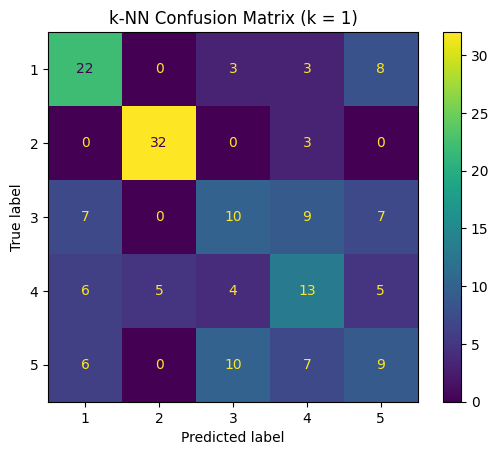


Classification Report:
              precision    recall  f1-score   support

           1       0.54      0.61      0.57        36
           2       0.86      0.91      0.89        35
           3       0.37      0.30      0.33        33
           4       0.37      0.39      0.38        33
           5       0.31      0.28      0.30        32

    accuracy                           0.51       169
   macro avg       0.49      0.50      0.49       169
weighted avg       0.50      0.51      0.50       169


Accuracy by Mine Type:
Mine Type 1: 22/36 = 61.11%
Mine Type 2: 32/35 = 91.43%
Mine Type 3: 10/33 = 30.30%
Mine Type 4: 13/33 = 39.39%
Mine Type 5: 9/32 = 28.12%


The optimal model used k = 1 and achieved an overall accuracy of 50.89% on the
test set. The confusion matrix shows that performance varied a lot across the 5
mine types. Mine Type 2 was classified the most accuractely with 32/35
observations being correct, which translates to a 91.43% accuracy. Mine Type 1
was also not 

In [24]:
print("-- Question 2.4 --")

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

# Fit the final model using the best k
knn = KNeighborsClassifier(n_neighbors=best_k)

knn.fit(X_train_scaled, y_train)

# Make predictions
y_pred = knn.predict(X_test_scaled)

# Overall accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Optimal k:", best_k)
print("Overall accuracy:", f"{accuracy:.2%}")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

cm_df = pd.DataFrame(
    cm,
    index=[
        "Actual 1",
        "Actual 2",
        "Actual 3",
        "Actual 4",
        "Actual 5"
    ],
    columns=[
        "Predicted 1",
        "Predicted 2",
        "Predicted 3",
        "Predicted 4",
        "Predicted 5"
    ]
)

print("\nConfusion Matrix:")
display(cm_df)

# Plot confusion matrix
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[1, 2, 3, 4, 5]
).plot()

plt.title(f"k-NN Confusion Matrix (k = {best_k})")
plt.show()

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Accuracy for ech mine type
print("\nAccuracy by Mine Type:")

for i in range(5):
    correct = cm[i, i]
    total = cm[i].sum()

    print(
        f"Mine Type {i + 1}: "
        f"{correct}/{total} = {correct / total:.2%}"
    )
print("\n")
text = "The optimal model used k = 1 and achieved an overall accuracy of 50.89% on the test set. The confusion matrix shows that performance varied a lot across the 5 mine types. Mine Type 2 was classified the most accuractely with 32/35 observations being correct, which translates to a 91.43% accuracy. Mine Type 1 was also not terrible with 22/36 correct classifications, being 61.11% accurate. Mine Types 3, 4, and 5 were classified correctly with 10/33 observations (30.0%), 13/33 observations (39.39%), and 9/32 observations (28.12%) respectively. There were also recurring classification errors, with Mine Type 5 being classified as Mine Type 3 10 times, Mine Type 3 as Mine Type 4 9 times, and Mine Type 1 as Mine Type 5 8 times. This showed that the model was really good at classifying Mine Type 2, but it struggled substantially on the other mine types. The accuracy of 50.89% does not completely describe this much better classification on Mine Type 2."
print(textwrap.fill(text, width=80))

In [25]:
print("-- Question 2.5 --")

# Get predicted probs
probabilities = knn.predict_proba(X_test_scaled)

# Create a small results table
results = pd.DataFrame({
    "actual": y_test.values,
    "predicted": y_pred,
    "confidence": probabilities.max(axis=1)
})

display(results.head(10))

# Look at some incorrect predictions
print("Incorrect predictions:")
display(
    results[
        results["actual"] != results["predicted"]
    ].head(10)
)

test = "I would not recommend using this model as the only mine type identifying method. Even though the model does correctly identify certain mine types very well, its overall accuracy is only slightly over 1/2, and we see that it makes immense mistakes with Mine Types 3-5. I recommend to use this model as an additional source of information rather than the final decision maker. It may help to look at the model's predicted probabilities or confidence rather than solely just a single predicted class. If the model as low confidence or predeicts a mine type that is often confused with another type, then more testing may be necessary. It's important with working with such a safety-critical issue such as land mines. An incorrect classification could lead to serious consequences. Therefore, this model may be useful for supporting a decision but should not take the primary role for making judgements or safety procedures."
print(textwrap.fill(test, width=80))

-- Question 2.5 --


,actual,predicted,confidence
0,3,1,1.0
1,1,4,1.0
2,4,4,1.0
3,4,1,1.0
4,3,3,1.0
5,3,3,1.0
6,4,3,1.0
7,4,1,1.0
8,2,4,1.0
9,4,2,1.0


Incorrect predictions:


,actual,predicted,confidence
0,3,1,1.0
1,1,4,1.0
3,4,1,1.0
6,4,3,1.0
7,4,1,1.0
8,2,4,1.0
9,4,2,1.0
13,3,4,1.0
14,5,4,1.0
17,5,4,1.0


I would not recommend using this model as the only mine type identifying method.
Even though the model does correctly identify certain mine types very well, its
overall accuracy is only slightly over 1/2, and we see that it makes immense
mistakes with Mine Types 3-5. I recommend to use this model as an additional
source of information rather than the final decision maker. It may help to look
at the model's predicted probabilities or confidence rather than solely just a
single predicted class. If the model as low confidence or predeicts a mine type
that is often confused with another type, then more testing may be necessary.
It's important with working with such a safety-critical issue such as land
mines. An incorrect classification could lead to serious consequences.
Therefore, this model may be useful for supporting a decision but should not
take the primary role for making judgements or safety procedures.


## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** 5b22b4470b1c33ce98823ee5594591baeea58da5
- **AI tool and model used:** ChatGPT: GPT-6 Astra

### *Prompts used

1. Hello, I have given you access to my assignment A3 for my DS 3001 course. This assignment is an kNN assignment. Please pay attention to the file, "notebook.ipynb." I have completed Phase 1 on my own. Please firstly analyze the problems being asked for Phase 1. Understand what I was supposed to do and the associated data in the /data directory. Afterwards, examine the code I wrote and the associated output to my code. After completely reviewing everything for Phase 1, you will be giving me revisions for Phase 2. Based on the questions, code, and output for Phase 1, what are the revisions you suggest to be incorporated in my code? Please identify mistakes, inconsistencies, and any possible fix you can give me to ensure my code and its output is efficient and correct.
2. Can you please view the code and output for Phase 2 that I created based on your revisions and verify that the revisions were all properly implemented and the overall code structure and accuracy is far better now? Please feel free to run the code yourself too to make sure everything works properly.

### *AI-proposed changes


1. **Q1.5 and Q2.3: distinguish validation performance from independent test performance.**

   You select \(k\) using `X_test`, then report performance on that same set. This follows the assignment’s wording—it explicitly permits a “test/validation” set—but the resulting 50.89% is **validation accuracy used for model selection**, not an independent estimate of future performance.

   Your statement that this procedure “ensures” the best generalization is too strong. It selects the best-performing candidate on this particular split.

   The minimum revision is to rename the holdout variables to `X_val` and `y_val`, label the results as validation results, and acknowledge possible selection optimism. A stronger revision is to retain the required 50/50 split and select \(k\) through stratified cross-validation **inside the training half**, using the other half only for final evaluation. Put scaling inside a pipeline so each fold learns its own scaling parameters. [Scikit-learn’s cross-validation guidance](https://scikit-learn.org/stable/modules/cross_validation.html)

   Because Phase 1 already examined the holdout, acknowledge that it is not a completely untouched test set across the whole assignment, even if Phase 2 improves the procedure.

2. **Q2.5: the reported “confidence” is misleading for your \(k=1\) model.**

   With one neighbor and uniform weighting, `predict_proba()` assigns probability 1.0 to that neighbor’s class and 0.0 to every other class. Consequently, **every prediction gets “confidence” 1.0—including all 83 errors**.

   This directly contradicts your suggestion to flag low-confidence predictions: that rule cannot flag anything in this model.

   Rename the column to something like `max_neighbor_vote_fraction` and explicitly explain its limitation. Larger \(k\) can produce more varied vote fractions, but those values still should not automatically be interpreted as calibrated probabilities of correctness. Do not select a larger \(k\) solely to make the probabilities look more informative. [KNeighborsClassifier documentation](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html)

3. **Q2.4: rename “Accuracy by Mine Type” to “Recall by Mine Type,” and discuss precision too.**

   Your calculation, `cm[i, i] / cm[i].sum()`, is class recall: among observations actually belonging to a class, how many were identified correctly?

   The distinction matters here:

   | Mine type | Precision: when predicted, how often correct? | Recall: how many actual cases found? |
   |---|---:|---:|
   | 1 | 53.66% | 61.11% |
   | 2 | 86.49% | 91.43% |
   | 3 | 37.04% | 30.30% |
   | 4 | 37.14% | 39.39% |
   | 5 | 31.03% | 28.12% |

   For example, Type 2 has 32 correct classifications out of 35 actual Type 2 observations, but **five Type 4 observations were incorrectly predicted as Type 2**. Its high recall does not mean every Type 2 prediction is reliable.

   Also correct the prose for Type 3: `10/33` is **30.30%**, not 30.0%. Your printed calculation is already correct.

4. **Q2.1: add interpretation to the EDA, especially for discrete features.**

   Your summaries and plots are useful, but the answer would benefit from a short explanation of what they reveal:

   - Class counts range from 65 to 71, so severe class imbalance is not the main problem.
   - Mean voltage is much higher for Type 2—about 0.721—than for the other classes, approximately 0.296–0.402. This is consistent with its stronger classification performance, although means alone do not establish separation.
   - `height` has only **12 distinct values**, and `soil` has **six**. Use value-count bar plots for these features, or bins aligned with their observed values. The default histogram bins can obscure their discrete structure.
   - Add a voltage-by-class boxplot to examine overlap.

   Investigate what `soil` represents. If its numbers encode unordered categories, Euclidean distance imposes an unjustified ordering; one-hot encoding would be worth considering. If the values represent a meaningful quantitative scale, numeric treatment may be appropriate. The files provided do not establish which interpretation is correct.

5. **Q2.3: keep scaling, but explain the choice accurately.**

   Your scaler is fitted correctly on training data only. There is no scaling leakage in the existing split.

   All three predictors already lie within approximately \([0,1]\), but their standard deviations differ. Standardization therefore changes their relative influence on distance; it is a reasonable modeling choice, not a guaranteed improvement. If you compare scaled and unscaled models, make that comparison within the training-side validation procedure.

6. **Q2.3–Q2.4: qualify “optimal,” explain ties, and add a baseline.**

   `accuracies.index(max(accuracies)) + 1` is correct for the current consecutive search range. It selects the smallest \(k\) if multiple values tie.

   Describe the result as “the best \(k\) among 1–30 under this evaluation procedure.” A selected \(k=1\) is not itself a coding error or proof of overfitting.

   Add a majority-class baseline. Classes 1 and 2 tie for most frequent in your training set; always predicting either yields approximately **21% holdout accuracy**. Your model improves substantially on that baseline, while still misclassifying nearly half the observations.

7. **Q1: refine the conceptual answers without rewriting the parts that are already correct.**

   Your regression/classification distinction, SSE formula, and overfitting/underfitting definitions are broadly correct. Useful additions are:

   - For Q1.2, explain that this five-class confusion matrix has actual classes as rows, predicted classes as columns, correct predictions on the diagonal, and mistakes elsewhere. TP/FP/FN/TN apply separately to each class versus the remaining classes.
   - For Q1.3, explain that squaring penalizes larger errors more heavily. SSE is not appropriate for treating mine labels 1–5 as numerical outcomes.
   - For Q1.4–1.5, connect small \(k\) to more flexible, potentially high-variance predictions and large \(k\) to smoother, potentially underfit predictions. Splitting data helps evaluate these problems; it does not automatically prevent them.
   - For Q1.6, distinguish estimated probabilities from verified confidence, using your \(k=1\) results as the concrete example.

8. **Q2.5: tie the practical conclusion to observed errors.**

   Your conclusion that this model should not be the sole decision-maker is appropriate. Strengthen it with specific evidence: 83 errors overall, low recall for Types 3–5, and incorrect predictions that nevertheless receive probability 1.0.

   Avoid implying that the model has demonstrated operational usefulness or that its probabilities can currently support a reliable confidence threshold. The experiment establishes performance on this dataset, not suitability for field use.

9. **Clean up repetition and make results harder to misreport.**

   Remove duplicate imports and the unused NumPy import. Define `features` and `labels` once, and pass `labels=[1, 2, 3, 4, 5]` explicitly to the confusion matrix and classification report.

   Generate numerical summaries from computed metrics rather than hard-coding them into paragraphs. Preserve original row indices in the predictions table with `index=y_test.index`. Restart the kernel and run all Phase 2 cells in order to verify that the revised solution is self-contained.

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / **modify** / reject | I think this is very fair. It's just a matter of better reporting, because the accuracy is not prediction accuracy, it is validation accuracy using the test data. I will not be making k be selected by looking at the training data because that goes against what the assignment states. |
| 2 | **Accept** / modify / reject | I think this is reasonable. With only one neighbor, my results appear very binary. I don't want to be misrepresenting what it means so I think renaming it to max_neighbor_vote_fraction makes a lot of sense here. |
| 3 | **Accept** / modify / reject | This is very true. The correct term and metric is recall and I want to make sure I am accurately using terminology correctly. |
| 4 | **Accept** / modify / reject | I agree that some explanations would really add to the EDA, since it shows my understanding of the results and the overall structure and design of the data. |
| 5 | **Accept** / modify / reject | I will add that explanation of the scaler. I see no harm in doing so because it only ensures that I am reporting things more accurately. |
| 6 | **Accept** / modify / reject | I agree that this once again ensures accurate reporting of my results. I think one thing AI really helps with is ensuring the way I am reporting things is as accurate as possible. I also think the majority class baseline would help a lot with model performance. |
| 7 | **Accept** / modify / reject | I see that these are just improvements to make my answers to Question 1 more descriptive and thorough. I appreciate that and will gladly take improvements. |
| 8 | **Accept** / modify / reject | I think associating the conclusion of using the model as a secondary source with the results can be done better since I give more of a high-level explanation rather than adding quantitative examples. |
| 9 | **Accept** / modify / reject | Making the overall code cleaner is always an important improvement. I don't want to write messy code that can be unintuitive and lead to confusions for those who look at my code. |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [26]:
import textwrap

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)


def print_paragraph(text):
    print(textwrap.fill(text, width=80))
    print()


# ============================================================
# Question 1: Conceptual questions
# ============================================================

print("-- Question 1.1 --")
print_paragraph(
    "Regression predicts numerical quantities, such as the price of a house, "
    "while classification predicts discrete labels or categories, such as "
    "whether an email is spam. Although mine_type uses the numbers 1 through "
    "5, these values represent class labels rather than numerical quantities, "
    "so predicting mine_type is a classification problem."
)

print("-- Question 1.2 --")
print_paragraph(
    "A confusion table compares actual class labels with predicted class "
    "labels. In the table used here, rows represent actual classes and columns "
    "represent predicted classes. Diagonal entries count correct predictions, "
    "while off-diagonal entries show which classes are confused with one "
    "another. For multiclass classification, true positives, false positives, "
    "false negatives, and true negatives can be defined separately for each "
    "class by comparing that class with all remaining classes. The table "
    "helps reveal errors that overall accuracy alone can hide."
)

print("-- Question 1.3 --")
print_paragraph(
    "SSE, or Sum of Squared Errors, measures the total squared difference "
    "between actual and predicted numerical values: "
    "SSE = sum((y_i - y_hat_i)^2). Squaring gives larger errors more weight. "
    "For models evaluated on the same observations and target scale, lower "
    "SSE indicates smaller total squared prediction error. SSE is suitable "
    "for regression, but it is not appropriate to apply it directly to the "
    "mine_type labels because numerical differences between these category "
    "codes do not represent meaningful amounts of error."
)

print("-- Question 1.4 --")
print_paragraph(
    "Overfitting occurs when a model captures details of the training data, "
    "including noise, that do not generalize well to new observations. "
    "Underfitting occurs when a model is too simple to capture useful "
    "patterns, leading to poor performance on both training and new data. "
    "For kNN, a small k produces more flexible predictions that can be "
    "sensitive to individual observations, while a large k produces smoother "
    "predictions that can overlook local patterns. A selected k of 1 is not, "
    "by itself, proof of overfitting."
)

print("-- Question 1.5 --")
print_paragraph(
    "Splitting the data allows us to evaluate predictions on observations "
    "that were not used to fit the model. Comparing candidate values of k "
    "using classification accuracy or regression SSE helps select a value "
    "that performs well on the held-out observations. However, splitting "
    "the data does not automatically prevent overfitting or underfitting, "
    "and the selected k is not guaranteed to perform best on future data. "
    "Following this assignment, I use a 50/50 training and validation split "
    "and select k using validation accuracy. Because the same validation "
    "set is used to select k and report the selected model's performance, "
    "that result is validation accuracy and may be optimistic. It is not "
    "an independent final test estimate."
)

print("-- Question 1.6 --")
print_paragraph(
    "A single predicted class label is simple to interpret and useful when "
    "one category must be reported, but it hides how support is distributed "
    "across the other classes. A probability distribution provides more "
    "information about the model's relative support for each class, but it "
    "is more complex to interpret and should not automatically be treated "
    "as calibrated confidence. With uniform-weight kNN, predicted "
    "probabilities are the fractions of neighbors belonging to each class. "
    "When k = 1, the selected class receives probability 1.0 even if the "
    "prediction is incorrect."
)

-- Question 1.1 --
Regression predicts numerical quantities, such as the price of a house, while
classification predicts discrete labels or categories, such as whether an email
is spam. Although mine_type uses the numbers 1 through 5, these values represent
class labels rather than numerical quantities, so predicting mine_type is a
classification problem.

-- Question 1.2 --
A confusion table compares actual class labels with predicted class labels. In
the table used here, rows represent actual classes and columns represent
predicted classes. Diagonal entries count correct predictions, while off-
diagonal entries show which classes are confused with one another. For
multiclass classification, true positives, false positives, false negatives, and
true negatives can be defined separately for each class by comparing that class
with all remaining classes. The table helps reveal errors that overall accuracy
alone can hide.

-- Question 1.3 --
SSE, or Sum of Squared Errors, measures the tota

-- Question 2.1 --


,voltage,height,soil,mine_type
0,0.338157,0.000000,0.0,1
1,0.320241,0.181818,0.0,1
2,0.287009,0.272727,0.0,1
3,0.256284,0.454545,0.0,1
4,0.262840,0.545455,0.0,1


Shape: (338, 4)

Data types:
voltage      float64
height       float64
soil         float64
mine_type      int64
dtype: object

Missing values:
voltage      0
height       0
soil         0
mine_type    0
dtype: int64

Duplicate rows: 0
Repeated predictor combinations: 0

Mine type counts:
mine_type
1    71
2    70
3    66
4    66
5    65
Name: count, dtype: int64

Mine type proportions:
mine_type
1    0.210059
2    0.207101
3    0.195266
4    0.195266
5    0.192308
Name: count, dtype: float64

Feature summary:


,voltage,height,soil
count,338.000000,338.000000,338.000000
mean,0.430634,0.508876,0.503550
std,0.195819,0.306043,0.344244
min,0.197734,0.000000,0.000000
25%,0.309737,0.272727,0.200000
50%,0.359516,0.545455,0.600000
75%,0.482628,0.727273,0.800000
max,0.999999,1.000000,1.000000



Number of distinct feature values:
voltage    196
height      12
soil         6
dtype: int64

Average feature values by mine type:


,voltage,height,soil
mine_type,,,
1,0.296463,0.495519,0.492958
2,0.721123,0.487013,0.508571
3,0.402408,0.527548,0.496970
4,0.345365,0.506887,0.503030
5,0.379598,0.530070,0.516923


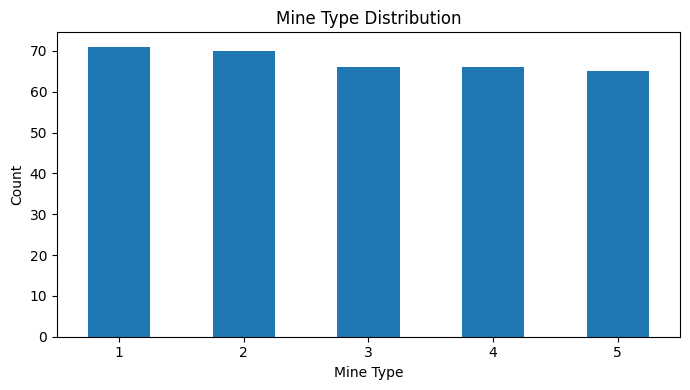

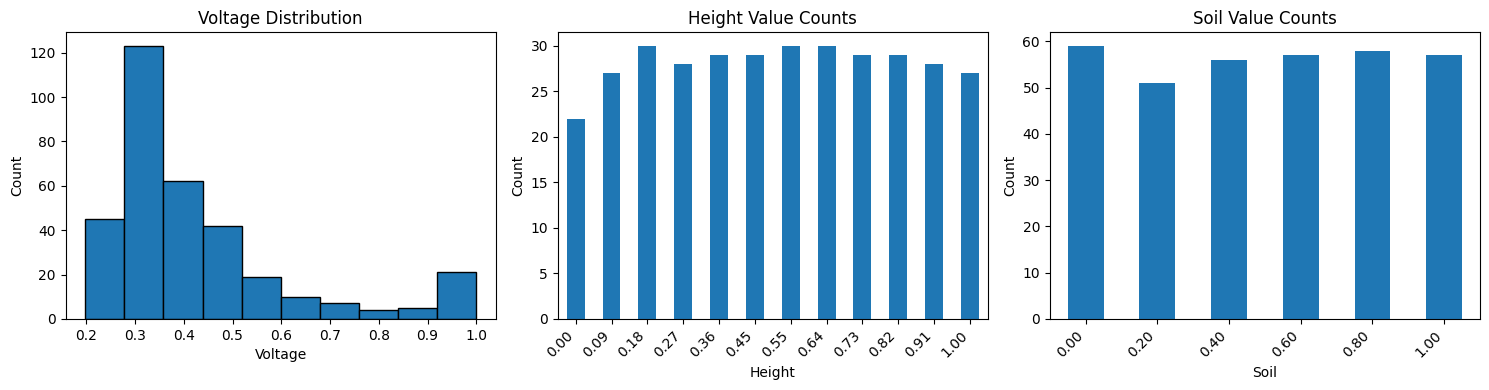

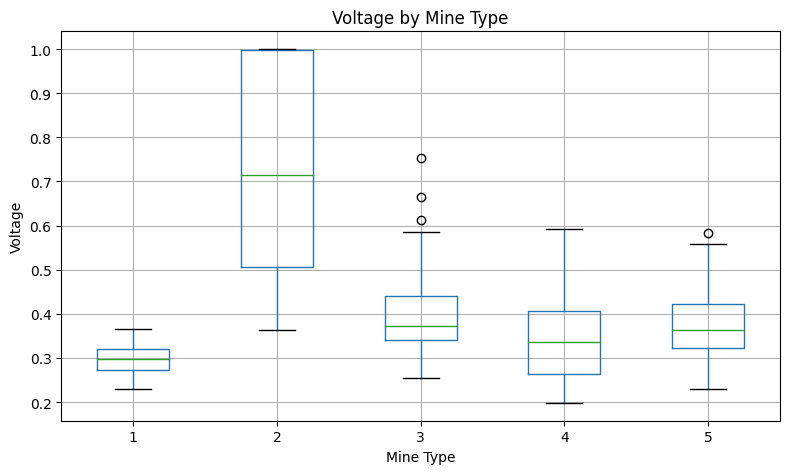

The dataset contains 338 observations and 3 predictors. Class counts range from
65 to 71, so the classes are fairly balanced. Severe class imbalance is
therefore unlikely to be the main source of classification difficulty.

Mean voltage for Mine Type 2 is 0.721, compared with a range of 0.296 to 0.402
for the other types. This suggests voltage may help distinguish Type 2, but
class means alone do not establish separation. The boxplot helps show the spread
and overlap of voltage values across classes.

Height has 12 distinct values, and soil has 6 distinct values. Value-count plots
show their discrete structure more clearly than default histogram bins. The
provided files do not establish whether soil is a quantitative measurement or an
unordered category code. I retain the original numeric representation, but this
is a modeling assumption: numerical distance between soil values may be
inappropriate if they are unordered categories.



In [27]:
# ============================================================
# Question 2.1: Load data and perform EDA
# ============================================================

print("-- Question 2.1 --")

features = ["voltage", "height", "soil"]
labels = [1, 2, 3, 4, 5]

df = pd.read_csv("data/land_mines.csv")

display(df.head())

print("Shape:", df.shape)

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isna().sum())

print("\nDuplicate rows:", df.duplicated().sum())
print(
    "Repeated predictor combinations:",
    df.duplicated(subset=features).sum(),
)

class_counts = df["mine_type"].value_counts().reindex(labels, fill_value=0)
class_proportions = class_counts / len(df)

print("\nMine type counts:")
print(class_counts)

print("\nMine type proportions:")
print(class_proportions)

print("\nFeature summary:")
display(df[features].describe())

print("\nNumber of distinct feature values:")
print(df[features].nunique())

feature_means = df.groupby("mine_type")[features].mean()

print("\nAverage feature values by mine type:")
display(feature_means)

# Target distribution
fig, ax = plt.subplots(figsize=(7, 4))
class_counts.plot(kind="bar", ax=ax)
ax.set_xlabel("Mine Type")
ax.set_ylabel("Count")
ax.set_title("Mine Type Distribution")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

# Voltage histogram and value-count plots for discrete features
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df["voltage"], bins=10, edgecolor="black")
axes[0].set_xlabel("Voltage")
axes[0].set_ylabel("Count")
axes[0].set_title("Voltage Distribution")

for ax, feature in zip(axes[1:], ["height", "soil"]):
    value_counts = df[feature].value_counts().sort_index()
    value_counts.plot(kind="bar", ax=ax)
    ax.set_xticklabels(
        [f"{value:.2f}" for value in value_counts.index],
        rotation=45,
        ha="right",
    )
    ax.set_xlabel(feature.capitalize())
    ax.set_ylabel("Count")
    ax.set_title(f"{feature.capitalize()} Value Counts")

plt.tight_layout()
plt.show()

# Compare voltage distributions across classes
fig, ax = plt.subplots(figsize=(8, 5))
df.boxplot(column="voltage", by="mine_type", ax=ax)
ax.set_xlabel("Mine Type")
ax.set_ylabel("Voltage")
ax.set_title("Voltage by Mine Type")
fig.suptitle("")
plt.tight_layout()
plt.show()

other_voltage_means = feature_means.loc[
    feature_means.index != 2, "voltage"
]

print_paragraph(
    f"The dataset contains {len(df)} observations and {len(features)} "
    f"predictors. Class counts range from {class_counts.min()} to "
    f"{class_counts.max()}, so the classes are fairly balanced. "
    "Severe class imbalance is therefore unlikely to be the main source "
    "of classification difficulty."
)

print_paragraph(
    f"Mean voltage for Mine Type 2 is "
    f"{feature_means.loc[2, 'voltage']:.3f}, compared with a range of "
    f"{other_voltage_means.min():.3f} to "
    f"{other_voltage_means.max():.3f} for the other types. "
    "This suggests voltage may help distinguish Type 2, but class means "
    "alone do not establish separation. The boxplot helps show the spread "
    "and overlap of voltage values across classes."
)

print_paragraph(
    f"Height has {df['height'].nunique()} distinct values, and soil has "
    f"{df['soil'].nunique()} distinct values. Value-count plots show their "
    "discrete structure more clearly than default histogram bins. The "
    "provided files do not establish whether soil is a quantitative "
    "measurement or an unordered category code. I retain the original "
    "numeric representation, but this is a modeling assumption: numerical "
    "distance between soil values may be inappropriate if they are "
    "unordered categories."
)

In [28]:
# ============================================================
# Question 2.2: Split 50/50 into training and validation sets
# ============================================================

print("-- Question 2.2 --")

X = df[features]
y = df["mine_type"]

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.5,
    random_state=42,
    stratify=y,
)

print("Training set size:", len(X_train))
print("Validation set size:", len(X_val))

train_class_counts = (
    y_train.value_counts().reindex(labels, fill_value=0)
)
val_class_counts = (
    y_val.value_counts().reindex(labels, fill_value=0)
)

print("\nTraining set class counts:")
print(train_class_counts)

print("\nValidation set class counts:")
print(val_class_counts)

print_paragraph(
    "I use a reproducible 50/50 split with stratification to preserve "
    "approximately the same class proportions in both subsets. The "
    "held-out half is called the validation set because it is used to "
    "choose k."
)

-- Question 2.2 --
Training set size: 169
Validation set size: 169

Training set class counts:
mine_type
1    35
2    35
3    33
4    33
5    33
Name: count, dtype: int64

Validation set class counts:
mine_type
1    36
2    35
3    33
4    33
5    32
Name: count, dtype: int64
I use a reproducible 50/50 split with stratification to preserve approximately
the same class proportions in both subsets. The held-out half is called the
validation set because it is used to choose k.



-- Question 2.3 --
kNN uses distances, so feature scaling affects which observations are considered
neighbors. Although all three predictors already lie approximately within [0,
1], their standard deviations differ. Standardization changes their relative
influence on distance; it is a reasonable modeling choice rather than a
guaranteed improvement. I fit the scaler only on training data and apply those
same parameters to validation data.

Best k among the candidates: 1
Values of k tied for best validation accuracy: [1]
Best validation accuracy: 50.89%


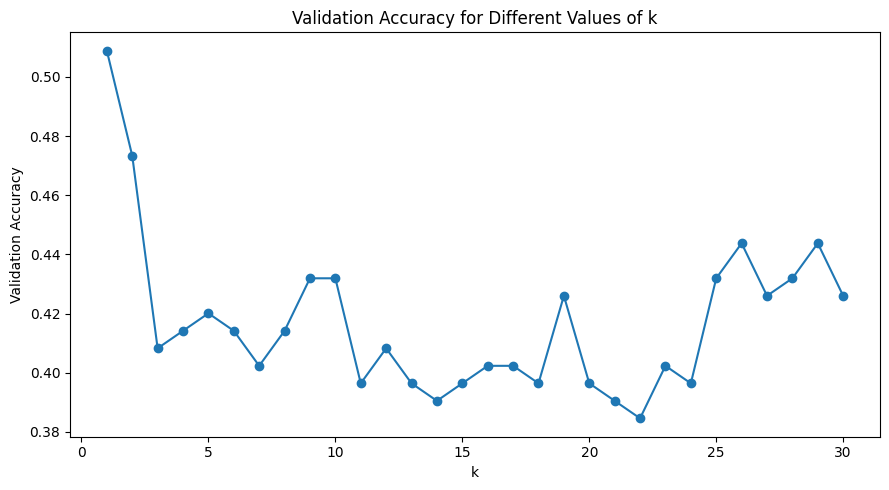

I evaluated k values from 1 through 30 and selected k = 1, which achieved the
highest validation accuracy. If multiple candidates tie, I choose the smallest
k. This identifies the best candidate under this evaluation procedure, not a
universally optimal k. Because I use the same validation set for selection and
reporting, the reported result may be optimistic and does not guarantee
performance on new data.


Majority-class baseline results:


,constant_predicted_class,validation_accuracy
0,1,0.213018
1,2,0.207101


The most frequent training class or classes are [1, 2]. The baseline predicts
one of these classes for every observation. When training counts tie, I report
each tied class's result rather than choosing between them using validation
performance. The baseline provides a comparison for evaluating kNN; it does not
change or improve the kNN predictions themselves.



In [29]:
# ============================================================
# Question 2.3: Scale features and select k
# ============================================================

print("-- Question 2.3 --")

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

print_paragraph(
    "kNN uses distances, so feature scaling affects which observations "
    "are considered neighbors. Although all three predictors already "
    "lie approximately within [0, 1], their standard deviations differ. "
    "Standardization changes their relative influence on distance; it "
    "is a reasonable modeling choice rather than a guaranteed "
    "improvement. I fit the scaler only on training data and apply "
    "those same parameters to validation data."
)

k_values = list(range(1, 31))
validation_accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)

    candidate_predictions = model.predict(X_val_scaled)
    validation_accuracies.append(
        accuracy_score(y_val, candidate_predictions)
    )

k_results = pd.DataFrame({
    "k": k_values,
    "validation_accuracy": validation_accuracies,
})

best_validation_accuracy = max(validation_accuracies)
tied_best_k = [
    k
    for k, score in zip(k_values, validation_accuracies)
    if score == best_validation_accuracy
]
best_k = min(tied_best_k)

print("Best k among the candidates:", best_k)
print("Values of k tied for best validation accuracy:", tied_best_k)
print(f"Best validation accuracy: {best_validation_accuracy:.2%}")

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(k_values, validation_accuracies, marker="o")
ax.set_xlabel("k")
ax.set_ylabel("Validation Accuracy")
ax.set_title("Validation Accuracy for Different Values of k")
plt.tight_layout()
plt.show()

print_paragraph(
    f"I evaluated k values from {min(k_values)} through {max(k_values)} "
    f"and selected k = {best_k}, which achieved the highest validation "
    "accuracy. If multiple candidates tie, I choose the smallest k. "
    "This identifies the best candidate under this evaluation procedure, "
    "not a universally optimal k. Because I use the same validation set "
    "for selection and reporting, the reported result may be optimistic "
    "and does not guarantee performance on new data."
)

# Majority-class baseline: identify ties using training labels only.
majority_classes = train_class_counts[
    train_class_counts == train_class_counts.max()
].index.tolist()

baseline_rows = []

for majority_class in majority_classes:
    baseline_accuracy = (y_val == majority_class).mean()
    baseline_rows.append({
        "constant_predicted_class": majority_class,
        "validation_accuracy": baseline_accuracy,
    })

baseline_results = pd.DataFrame(baseline_rows)

print("\nMajority-class baseline results:")
display(baseline_results)

print_paragraph(
    f"The most frequent training class or classes are {majority_classes}. "
    "The baseline predicts one of these classes for every observation. "
    "When training counts tie, I report each tied class's result rather "
    "than choosing between them using validation performance. The "
    "baseline provides a comparison for evaluating kNN; it does not "
    "change or improve the kNN predictions themselves."
)

-- Question 2.4 --
Selected k: 1
Evaluation set: validation set used to select k
Overall validation accuracy: 50.89%

Confusion Matrix:


,Predicted 1,Predicted 2,Predicted 3,Predicted 4,Predicted 5
Actual 1,22,0,3,3,8
Actual 2,0,32,0,3,0
Actual 3,7,0,10,9,7
Actual 4,6,5,4,13,5
Actual 5,6,0,10,7,9


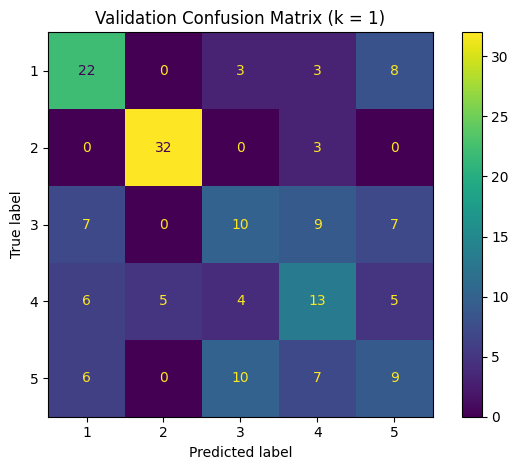


Classification Report:
              precision    recall  f1-score   support

           1       0.54      0.61      0.57        36
           2       0.86      0.91      0.89        35
           3       0.37      0.30      0.33        33
           4       0.37      0.39      0.38        33
           5       0.31      0.28      0.30        32

    accuracy                           0.51       169
   macro avg       0.49      0.50      0.49       169
weighted avg       0.50      0.51      0.50       169


Precision and Recall by Mine Type:


,correct,actual_count,predicted_count,precision,recall
mine_type,,,,,
1,22,36,41,0.536585,0.611111
2,32,35,37,0.864865,0.914286
3,10,33,27,0.370370,0.303030
4,13,33,35,0.371429,0.393939
5,9,32,29,0.310345,0.281250



Recall by Mine Type:
Mine Type 1: 22/36 = 61.11%
Mine Type 2: 32/35 = 91.43%
Mine Type 3: 10/33 = 30.30%
Mine Type 4: 13/33 = 39.39%
Mine Type 5: 9/32 = 28.12%
Recall measures the fraction of actual observations of a class that were
correctly identified. Precision measures the fraction of predictions of a class
that were correct. These answer different questions, so I report both rather
than describing recall as class-specific accuracy.

The selected model uses k = 1 and correctly classifies 86 of 169 validation
observations, giving 50.89% validation accuracy and 83 errors. Type 2 has the
highest recall at 91.43%. The class-level results show that overall accuracy
hides substantial differences in performance.

Type 1: the model correctly identifies 22 of 36 actual observations, for recall
of 61.11%. Of 41 predictions of this type, 22 are correct, giving precision of
53.66%.

Type 2: the model correctly identifies 32 of 35 actual observations, for recall
of 91.43%. Of 37 predictions of

In [30]:
# ============================================================
# Question 2.4: Evaluate the selected model
# ============================================================

print("-- Question 2.4 --")

knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train_scaled, y_train)

y_pred = knn.predict(X_val_scaled)
validation_accuracy = accuracy_score(y_val, y_pred)

print("Selected k:", best_k)
print("Evaluation set: validation set used to select k")
print(f"Overall validation accuracy: {validation_accuracy:.2%}")

cm = confusion_matrix(y_val, y_pred, labels=labels)

cm_df = pd.DataFrame(
    cm,
    index=[f"Actual {label}" for label in labels],
    columns=[f"Predicted {label}" for label in labels],
)

print("\nConfusion Matrix:")
display(cm_df)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels,
).plot()

plt.title(f"Validation Confusion Matrix (k = {best_k})")
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(
    classification_report(
        y_val,
        y_pred,
        labels=labels,
        zero_division=0,
    )
)

class_metric_rows = []

for i, label in enumerate(labels):
    correct = int(cm[i, i])
    actual_total = int(cm[i, :].sum())
    predicted_total = int(cm[:, i].sum())

    recall = correct / actual_total if actual_total else 0.0
    precision = correct / predicted_total if predicted_total else 0.0

    class_metric_rows.append({
        "mine_type": label,
        "correct": correct,
        "actual_count": actual_total,
        "predicted_count": predicted_total,
        "precision": precision,
        "recall": recall,
    })

class_metrics = pd.DataFrame(class_metric_rows).set_index("mine_type")

print("\nPrecision and Recall by Mine Type:")
display(class_metrics)

print("\nRecall by Mine Type:")
for label, row in class_metrics.iterrows():
    print(
        f"Mine Type {label}: "
        f"{int(row['correct'])}/{int(row['actual_count'])} "
        f"= {row['recall']:.2%}"
    )

print_paragraph(
    "Recall measures the fraction of actual observations of a class "
    "that were correctly identified. Precision measures the fraction "
    "of predictions of a class that were correct. These answer "
    "different questions, so I report both rather than describing "
    "recall as class-specific accuracy."
)

correct_predictions = int(cm.trace())
incorrect_predictions = int(cm.sum() - cm.trace())
best_recall_class = class_metrics["recall"].idxmax()

print_paragraph(
    f"The selected model uses k = {best_k} and correctly classifies "
    f"{correct_predictions} of {len(y_val)} validation observations, "
    f"giving {validation_accuracy:.2%} validation accuracy and "
    f"{incorrect_predictions} errors. Type {best_recall_class} has "
    f"the highest recall at "
    f"{class_metrics.loc[best_recall_class, 'recall']:.2%}. "
    "The class-level results show that overall accuracy hides "
    "substantial differences in performance."
)

for label in labels:
    row = class_metrics.loc[label]
    print_paragraph(
        f"Type {label}: the model correctly identifies "
        f"{int(row['correct'])} of {int(row['actual_count'])} actual "
        f"observations, for recall of {row['recall']:.2%}. "
        f"Of {int(row['predicted_count'])} predictions of this type, "
        f"{int(row['correct'])} are correct, giving precision of "
        f"{row['precision']:.2%}."
    )

type_4_as_2 = int(cm[labels.index(4), labels.index(2)])

print_paragraph(
    f"Although Type 2 has recall of "
    f"{class_metrics.loc[2, 'recall']:.2%}, its precision is "
    f"{class_metrics.loc[2, 'precision']:.2%}. "
    f"In particular, {type_4_as_2} actual Type 4 observations were "
    "predicted as Type 2. High recall therefore does not mean every "
    "prediction of that type is correct."
)

for actual, predicted in [(5, 3), (3, 4), (1, 5)]:
    error_count = int(cm[labels.index(actual), labels.index(predicted)])
    print(
        f"Actual Type {actual} predicted as Type {predicted}: "
        f"{error_count}"
    )

In [31]:
# ============================================================
# Question 2.5: Interpret vote fractions and practical limitations
# ============================================================

print("\n-- Question 2.5 --")

probabilities = knn.predict_proba(X_val_scaled)

results = pd.DataFrame(
    {
        "actual": y_val,
        "predicted": y_pred,
        "max_neighbor_vote_fraction": probabilities.max(axis=1),
    },
    index=y_val.index,
)

print("\nExample predictions (original dataset row indices preserved):")
display(results.head(10))

incorrect_results = results[
    results["actual"] != results["predicted"]
]

print("\nIncorrect predictions:")
display(incorrect_results.head(10))

print_paragraph(
    "The max_neighbor_vote_fraction column is the largest fraction "
    "of neighbors voting for one class. It is not a verified "
    "probability that the prediction is correct."
)

if best_k == 1:
    print_paragraph(
        f"With k = 1, every prediction has a maximum neighbor vote "
        f"fraction of 1.0, including all {len(incorrect_results)} "
        "incorrect predictions. A rule that flags low vote fractions "
        "would therefore flag no observations and would fail to "
        "identify these errors. Larger k values can produce more "
        "varied vote fractions, but those fractions are not "
        "automatically calibrated probabilities of correctness."
    )

weak_class_recalls = "; ".join(
    f"Type {label}: {class_metrics.loc[label, 'recall']:.2%}"
    for label in [3, 4, 5]
)

print_paragraph(
    f"I would not recommend using this model as the sole method for "
    f"identifying mine types. It makes {incorrect_predictions} errors "
    f"out of {len(y_val)} validation observations. Recall is "
    f"particularly limited for Types 3–5 ({weak_class_recalls}). "
    f"Even Type 2 predictions include {type_4_as_2} observations "
    "that actually belong to Type 4."
)

print_paragraph(
    "At most, these predictions could be considered an additional "
    "source of information requiring independent verification, "
    "rather than a final decision or the basis for safety procedures. "
    "This experiment does not demonstrate suitability for field use "
    "or establish a reliable confidence threshold. The dataset is "
    "small, performance depends on the chosen split, and the same "
    "validation observations were used to select k and report its "
    "performance."
)


-- Question 2.5 --

Example predictions (original dataset row indices preserved):


,actual,predicted,max_neighbor_vote_fraction
285,3,1,1.0
238,1,4,1.0
177,4,4,1.0
305,4,1,1.0
101,3,3,1.0
125,3,3,1.0
141,4,3,1.0
169,4,1,1.0
54,2,4,1.0
154,4,2,1.0



Incorrect predictions:


,actual,predicted,max_neighbor_vote_fraction
285,3,1,1.0
238,1,4,1.0
305,4,1,1.0
141,4,3,1.0
169,4,1,1.0
54,2,4,1.0
154,4,2,1.0
277,3,4,1.0
334,5,4,1.0
219,5,4,1.0


The max_neighbor_vote_fraction column is the largest fraction of neighbors
voting for one class. It is not a verified probability that the prediction is
correct.

With k = 1, every prediction has a maximum neighbor vote fraction of 1.0,
including all 83 incorrect predictions. A rule that flags low vote fractions
would therefore flag no observations and would fail to identify these errors.
Larger k values can produce more varied vote fractions, but those fractions are
not automatically calibrated probabilities of correctness.

I would not recommend using this model as the sole method for identifying mine
types. It makes 83 errors out of 169 validation observations. Recall is
particularly limited for Types 3–5 (Type 3: 30.30%; Type 4: 39.39%; Type 5:
28.12%). Even Type 2 predictions include 5 observations that actually belong to
Type 4.

At most, these predictions could be considered an additional source of
information requiring independent verification, rather than a final decision or
t

### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]

AI once again does an amazing job of making sure that my code and outputs are as intuitive and accurately reported as possible. A majority of the changes were fixing the way things are reported or clarifying limitations to ensure no confusion. I think the AI did think it was completly correct and tried to go against what the assignment for the first revision, which surprised me because I did not expect the AI to go past the guidelines themselves, which it did have access to since it could see question 1.5 which states k should use the testing data. Other than that, the AI was very useful and gave me great additions and changes to ensure everything was very readable and accurate. I verified the final solution by asking the AI to check the Phase 2 code and make any changes as it thinks is necessary. It added a lot more explanations which I appreciated because it once again just makes sure I am reporting as much as possible.